# Narrow-Beam Lidar Validation: ICESat-2

The Ice, Cloud, and land Elevation Satellite-2 ([ICESat-2](https://icesat-2.gsfc.nasa.gov/)) carries the Advanced Topographic Laser Altimeter System (ATLAS), which measures heights along six ground tracks: three pairs of beams, about 3.3 km apart across track, each with a strong and a weak beam about 90 m apart. Each laser footprint is only about 11 m wide, and the spacecraft is pointed so that its central pair of beams follows one of 1,387 reference ground tracks (RGTs), which repeat every 91 days. Such narrow instruments test the limits of TAT-C's orbit propagation from public two-line element (TLE) sets, whose errors are typically hundreds of meters. This notebook compares TAT-C with the ground tracks ICESat-2 observed from 21 September to 2 October 2026, and asks:

1. **Orbit and repeat cycle.** How accurately does TAT-C's propagation of a TLE predict ICESat-2's equator crossings, and does TAT-C recognize its 91-day repeat cycle?
2. **Beam tracks.** Where are the six beams relative to TAT-C's ground track?
3. **Narrow views.** How wide must a modeled view be for TAT-C to predict where the beams observe?

## Reference Data

The ATLAS/ICESat-2 Land and Vegetation Height Quick Look product (ATL08QL, version 7) from the [National Snow and Ice Data Center](https://nsidc.org/data/icesat-2) (NSIDC), available within days of acquisition, reports heights for 100 m segments of each beam over land, with their locations and times. Each file covers one of 14 regions of an orbit; its orbit information includes the RGT, the time and longitude at which the orbit crosses the equator northward (ascending node), and the spacecraft orientation. Downloading requires a free [NASA Earthdata Login](https://urs.earthdata.nasa.gov/) account and the `earthaccess` package; only the needed variables are read, with HTTP range requests. The first run takes about 15 minutes; reduced data are cached in a local `data/icesat2` directory.

ICESat-2 is modeled with a TLE from [CelesTrak](https://celestrak.org/) whose epoch (4 October 2026, 13:41 UTC) follows the analysis period by 2 to 13 days.

In [1]:
import concurrent.futures
import re
from datetime import datetime, timedelta, timezone
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pyproj import Geod
from skyfield.api import wgs84
from skyfield.framelib import itrs

from tatc.analysis import collect_observations
from tatc.constants import EARTH_MEAN_RADIUS, timescale
from tatc.schemas import GeneralPerturbationsOrbit, Point, PointedInstrument, Satellite

DATA_DIR = Path("data") / "icesat2"
DATA_DIR.mkdir(parents=True, exist_ok=True)
START = datetime(2026, 9, 21, tzinfo=timezone.utc)
END = datetime(2026, 10, 3, tzinfo=timezone.utc)
TLE = [
    "1 43613U 18070A   26277.57046165  .00001587  00000+0  57409-4 0  9990",
    "2 43613  91.9994 320.5065 0005609  71.5392 288.6467 15.28297940449160",
]
TLE_EPOCH = datetime(2026, 10, 4, 13, 41, 28, tzinfo=timezone.utc)
GPS_EPOCH = datetime(1980, 1, 6, tzinfo=timezone.utc)
GPS_UTC = 18  # s
BEAMS = ["gt1l", "gt1r", "gt2l", "gt2r", "gt3l", "gt3r"]
CROSSINGS_FILE = DATA_DIR / f"atl08ql_crossings_{START:%Y%m%d}_{END - timedelta(days=1):%Y%m%d}.csv"
SEGMENTS_FILE = DATA_DIR / f"atl08ql_segments_{START:%Y%m%d}_{END - timedelta(days=1):%Y%m%d}.csv"
geod = Geod(ellps="WGS84")


def gps_seconds_to_utc(seconds):
    """UTC times of GPS seconds since 6 January 1980."""
    return pd.to_datetime(GPS_EPOCH) + pd.to_timedelta(np.asarray(seconds) - GPS_UTC, unit="s")


if not (CROSSINGS_FILE.exists() and SEGMENTS_FILE.exists()):
    import io

    import earthaccess
    import h5py
    import requests

    earthaccess.login()
    session = earthaccess.get_requests_https_session()

    class RemoteFile(io.RawIOBase):
        """Read-only file object that downloads blocks of a remote file with HTTP range requests on demand."""

        def __init__(self, url, block_size=2**16, prefetch=4):
            self.block_size, self.blocks, self.position = block_size, {}, 0
            # follow the Earthdata Login redirects while prefetching the first blocks (file metadata)
            response = self._get(url, 0, prefetch * block_size)
            self.url, self.size = response.url, int(response.headers["Content-Range"].split("/")[1])
            self._store(0, response.content)

        def _get(self, url, start, end):
            for attempt in range(5):
                try:
                    response = session.get(url, headers={"Range": f"bytes={start}-{end - 1}"}, timeout=300)
                    response.raise_for_status()
                    return response
                except requests.RequestException:
                    if attempt == 4:
                        raise

        def _store(self, first, content):
            for i in range(0, len(content), self.block_size):
                self.blocks[first + i // self.block_size] = content[i : i + self.block_size]

        def readable(self):
            return True

        def seekable(self):
            return True

        def tell(self):
            return self.position

        def seek(self, offset, whence=io.SEEK_SET):
            self.position = {io.SEEK_SET: 0, io.SEEK_CUR: self.position, io.SEEK_END: self.size}[whence] + offset
            return self.position

        def readinto(self, buffer):
            n = min(len(buffer), self.size - self.position)
            if n <= 0:
                return 0
            first, last = self.position // self.block_size, (self.position + n - 1) // self.block_size
            missing = [block for block in range(first, last + 1) if block not in self.blocks]
            if missing:
                end = min((missing[-1] + 1) * self.block_size, self.size)
                self._store(missing[0], self._get(self.url, missing[0] * self.block_size, end).content)
            data = b"".join(self.blocks[block] for block in range(first, last + 1))
            offset = self.position - first * self.block_size
            buffer[:n] = data[offset : offset + n]
            self.position += n
            return n

    results = earthaccess.search_data(short_name="ATL08QL", version="007", temporal=(START.strftime("%Y-%m-%dT%H:%M:%SZ"), (END - timedelta(seconds=1)).strftime("%Y-%m-%dT%H:%M:%SZ")))
    names = [r["umm"]["GranuleUR"] for r in results]
    rgts = [int(re.search(r"_(\d{4})(\d{2})(\d{2})_", n).group(1)) for n in names]
    urls = [next(link["URL"] for link in r["umm"]["RelatedUrls"] if link["URL"].startswith("https") and link["URL"].endswith(".h5")) for r in results]
    # one file per RGT for the orbit information, and every 10th file for the segments
    first_of_rgt = sorted({rgt: i for i, rgt in reversed(list(enumerate(rgts)))}.values())
    sample = sorted(set(range(0, len(results), 10)) | set(first_of_rgt))

    def read(i):
        """Orbit information and (for sampled files) beam segments of a file."""
        with h5py.File(RemoteFile(urls[i]), "r") as f:
            epoch = float(f["ancillary_data/atlas_sdp_gps_epoch"][0])
            orbit = {
                "file": names[i],
                "rgt": int(f["orbit_info/rgt"][0]),
                "cycle": int(f["orbit_info/cycle_number"][0]),
                # crossing time in seconds since the ATLAS epoch (2018-01-01, GPS time)
                "crossing_gps_seconds": epoch + float(f["orbit_info/crossing_time"][0]),
                "lan": float(f["orbit_info/lan"][0]),
                "sc_orient": int(f["orbit_info/sc_orient"][0]),
            }
            segments = []
            if i % 10 == 0:
                for beam in BEAMS:
                    if f"{beam}/land_segments" in f:
                        group = f[f"{beam}/land_segments"]
                        segments.append(
                            pd.DataFrame(
                                {
                                    "file": names[i],
                                    "beam": beam,
                                    "beam_type": f[beam].attrs["atlas_beam_type"].decode() if isinstance(f[beam].attrs["atlas_beam_type"], bytes) else str(f[beam].attrs["atlas_beam_type"]),
                                    # every 10th segment (about 1 km apart)
                                    "latitude": group["latitude"][::10],
                                    "longitude": group["longitude"][::10],
                                    "gps_seconds": epoch + group["delta_time"][::10],
                                }
                            )
                        )
        return orbit, segments

    with concurrent.futures.ThreadPoolExecutor(8) as pool:
        outputs = list(pool.map(read, sample))
    pd.DataFrame([o for o, _ in outputs]).drop_duplicates("rgt").to_csv(CROSSINGS_FILE, index=False)
    pd.concat([s for _, segments in outputs for s in segments]).to_csv(SEGMENTS_FILE, index=False)
crossings = pd.read_csv(CROSSINGS_FILE)
crossings["time"] = gps_seconds_to_utc(crossings.crossing_gps_seconds)
segments = pd.read_csv(SEGMENTS_FILE)
segments["time"] = gps_seconds_to_utc(segments.gps_seconds)
icesat2 = GeneralPerturbationsOrbit.from_tle(TLE)
BLUE, ORANGE, AQUA, GRAY, INK, PURPLE = "#2a78d6", "#eb6834", "#1baf7a", "#8a8984", "#0b0b0b", "#8e5bd8"
plt.rcParams.update({"axes.spines.top": False, "axes.spines.right": False, "axes.grid": True, "grid.color": "#e6e5e0", "grid.linewidth": 0.6})
pd.Series(
    {
        "orbits (RGTs)": len(crossings),
        "cycle": ", ".join(map(str, sorted(crossings.cycle.unique()))),
        "spacecraft orientation (0: backward, 1: forward)": ", ".join(map(str, sorted(crossings.sc_orient.unique()))),
        "files with segments": segments.file.nunique(),
        "segments (every 10th)": len(segments),
    }
)

orbits (RGTs)                                          173
cycle                                                   33
spacecraft orientation (0: backward, 1: forward)         1
files with segments                                    176
segments (every 10th)                               816539
dtype: object

## Test 1: Orbit and Repeat Cycle

For each orbit, TAT-C's ascending node is found by propagating the TLE (SGP4) around the reported crossing time and locating the northward equator crossing of its ground track. Its time and longitude are compared with the reported ones.

In [2]:
satrec = icesat2.elements[0].to_skyfield()


def ascending_node(time):
    """Time and longitude of TAT-C's northward equator crossing nearest a time."""
    offsets = np.arange(-120, 120.01, 0.25)
    times = [time.floor("us").to_pydatetime() + timedelta(seconds=float(s)) for s in offsets]
    latitude = wgs84.subpoint_of(satrec.at(timescale.from_datetimes(times))).latitude.degrees
    k = np.nonzero((latitude[:-1] < 0) & (latitude[1:] >= 0))[0][0]
    fraction = -latitude[k] / (latitude[k + 1] - latitude[k])
    crossing = times[k] + (times[k + 1] - times[k]) * fraction
    longitude = wgs84.subpoint_of(satrec.at(timescale.from_datetime(crossing))).longitude.degrees
    return crossing, float(longitude)


nodes = [ascending_node(t) for t in crossings.time]
crossings["days before TLE epoch"] = (TLE_EPOCH - crossings.time) / timedelta(days=1)
crossings["time difference (s)"] = [(t - c).total_seconds() for (t, _), c in zip(nodes, crossings.time)]
crossings["longitude difference (km)"] = [((lon - lan + 180) % 360 - 180) * np.pi / 180 * 6378.137 for (_, lon), lan in zip(nodes, crossings.lan)]
crossings["bin"] = pd.cut(crossings["days before TLE epoch"], [0, 4, 6, 8, 10, 12, 14])
crossings.groupby("bin", observed=True).agg(
    **{
        "orbits": ("rgt", "size"),
        "time difference, median (s)": ("time difference (s)", "median"),
        "time difference, max |x| (s)": ("time difference (s)", lambda x: x.abs().max()),
        "longitude difference, median (km)": ("longitude difference (km)", "median"),
        "longitude difference, max |x| (km)": ("longitude difference (km)", lambda x: x.abs().max()),
    }
).round(3)

,orbits,"time difference, median (s)","time difference, max |x| (s)","longitude difference, median (km)","longitude difference, max |x| (km)"
bin,,,,,
"(0, 4]",37,0.044,0.206,-1.107,1.504
"(4, 6]",30,-0.019,0.188,-1.663,1.928
"(6, 8]",31,-0.182,0.328,-1.870,2.049
"(8, 10]",30,-0.227,0.406,-1.698,1.962
"(10, 12]",20,-2.838,3.544,-1.096,1.526
"(12, 14]",25,-4.648,5.214,-0.334,0.859


Over the 10 days before the TLE's epoch, TAT-C's ascending nodes agree with ICESat-2's to within 0.4 s in time and 2 km in longitude (TAT-C's nodes lie 1 to 2 km west of ICESat-2's). Earlier, they precede ICESat-2's by 3 to 5 s, consistent with an adjustment of ICESat-2's orbit about 10 days before the TLE's epoch, which the TLE does not represent.

TAT-C searches for an orbit's repeat cycle (`get_repeat_cycle`) within a maximum duration (the `repeat_cycle_search_duration_days` setting, 30 days by default): it shortlists whole numbers of orbits per whole number of nodal days from SGP4's secular rates, and confirms a candidate if the propagated satellite returns to within 10 km (and 3 m/s) of its initial Earth-fixed position. The repeat cycle of the TLE's orbit is computed with the default and with a 100-day search, and compared with the number of orbits in 91 nodal days from the secular rates and with the propagated satellite's closest approach to its initial Earth-fixed position after 91 days.

In [3]:
default_cycle = icesat2.get_repeat_cycle()
long_cycle = GeneralPerturbationsOrbit.from_tle(TLE).get_repeat_cycle(max_search_duration=timedelta(days=100))
model = satrec.model
nodal_period = 2 * np.pi / (model.mdot + model.argpdot) * 60
nodal_day = 2 * np.pi / (2 * np.pi / 86164.0905 * 60 - model.nodedot) * 60
epoch = icesat2.elements[0].epoch
initial = np.array(satrec.at(timescale.from_datetime(epoch)).frame_xyz(itrs).m)
later = [epoch + timedelta(days=91, seconds=float(x)) for x in np.arange(-3000, 3000, 5)]
distance = np.linalg.norm(np.array(satrec.at(timescale.from_datetimes(later)).frame_xyz(itrs).m).T - initial, axis=1)
pd.Series(
    {
        "repeat cycle, 30-day search (default)": str(default_cycle),
        "repeat cycle, 100-day search": str(long_cycle),
        "orbits in 91 nodal days (secular rates)": 91 * nodal_day / nodal_period,
        "closest approach to initial Earth-fixed position after 91 days, propagated (km)": distance.min() / 1e3,
    }
)

repeat cycle, 30-day search (default)                                                     None
repeat cycle, 100-day search                                                              None
orbits in 91 nodal days (secular rates)                                            1387.020321
closest approach to initial Earth-fixed position after 91 days, propagated (km)    7536.038723
dtype: object

TAT-C's repeat-cycle search does not find ICESat-2's 91-day repeat cycle, even when extended to 100 days. The secular rates of the TLE's orbit are consistent with it (1,387.02 orbits in 91 nodal days, for 1,387 RGTs), but propagated by SGP4, which includes the TLE's drag, the satellite is 7,500 km from its initial Earth-fixed position after 91 days: ICESat-2 repeats its ground tracks only because it is maneuvered against drag. TAT-C thus cannot confirm the repeat cycle of a maintained low orbit whose repeat cycle is long compared with the effect of drag (and does not search beyond 30 days by default).

## Test 2: Beam Tracks

Each beam segment (every 10th, about 1 km apart) is located relative to TAT-C's ground track at the segment's time: across track (positive to the left of the direction of motion) and along track (positive ahead of TAT-C's satellite). ICESat-2 points its beams at the RGTs over the polar ice sheets, but over land at lower latitudes it points them off the RGTs (by up to about 15 km) to map vegetation on a denser grid, so the segments are grouped by region.

In [4]:
def beam_offsets(group):
    """Cross- and along-track offsets (km) of beam segments from TAT-C's ground track."""
    times = timescale.from_datetimes(list(group.time.dt.floor("us")))
    track = satrec.at(times)
    ahead = satrec.at(timescale.tt_jd(times.tt + 1 / 86400))
    now, later = wgs84.subpoint_of(track), wgs84.subpoint_of(ahead)
    heading = geod.inv(now.longitude.degrees, now.latitude.degrees, later.longitude.degrees, later.latitude.degrees)[0]
    azimuth, _, distance = geod.inv(now.longitude.degrees, now.latitude.degrees, group.longitude.to_numpy(), group.latitude.to_numpy())
    angle = np.radians(azimuth - heading)
    return group.assign(**{"cross-track (km)": -distance * np.sin(angle) / 1e3, "along-track (km)": distance * np.cos(angle) / 1e3})


segments = pd.concat([beam_offsets(g) for _, g in segments.groupby("file")])
segments["days before TLE epoch"] = (TLE_EPOCH - segments.time) / timedelta(days=1)
segments["region"] = np.where(segments.latitude < -60, "Antarctica (south of 60 deg S)", np.where(segments.latitude > 60, "north of 60 deg N", "60 deg S to 60 deg N"))
table2 = segments.groupby(["region", "beam", "beam_type"]).agg(
    **{
        "segments": ("latitude", "size"),
        "cross-track, median (km)": ("cross-track (km)", "median"),
        "cross-track, 5th percentile (km)": ("cross-track (km)", lambda x: x.quantile(0.05)),
        "cross-track, 95th percentile (km)": ("cross-track (km)", lambda x: x.quantile(0.95)),
        "along-track, median (km)": ("along-track (km)", "median"),
    }
)
table2.round(3)

segments  \
region                         beam beam_type             
60 deg S to 60 deg N           gt1l weak          50485   
                               gt1r strong        64710   
                               gt2l weak          48967   
                               gt2r strong        62887   
                               gt3l weak          50326   
                               gt3r strong        64342   
Antarctica (south of 60 deg S) gt1l weak          65666   
                               gt1r strong        68773   
                               gt2l weak          64294   
                               gt2r strong        67082   
                               gt3l weak          64031   
                               gt3r strong        67332   
north of 60 deg N              gt1l weak          11475   
                               gt1r strong        14434   
                               gt2l weak          11379   
                               gt2r strong        13988   
                               gt3l weak          11768   
                               gt3r strong        14600   

                                               cross-track, median (km)  \
region                         beam beam_type                             
60 deg S to 60 deg N           gt1l weak                         13.789   
                               gt1r strong                       13.803   
                               gt2l weak                         10.556   
                               gt2r strong                       10.546   
                               gt3l weak                          7.329   
                               gt3r strong                        7.344   
Antarctica (south of 60 deg S) gt1l weak                          2.961   
                               gt1r strong                        2.868   
                               gt2l weak                         -0.403   
                               gt2r strong                       -0.501   
                               gt3l weak                         -3.777   
                               gt3r strong                       -3.876   
north of 60 deg N              gt1l weak                          3.825   
                               gt1r strong                        3.969   
                               gt2l weak                          0.535   
                               gt2r strong                        0.701   
                               gt3l weak                         -2.619   
                               gt3r strong                       -2.479   

                                               cross-track, 5th percentile (km)  \
region                         beam beam_type                                     
60 deg S to 60 deg N           gt1l weak                                  1.948   
                               gt1r strong                                1.855   
                               gt2l weak                                 -1.238   
                               gt2r strong                               -1.334   
                               gt3l weak                                 -4.435   
                               gt3r strong                               -4.533   
Antarctica (south of 60 deg S) gt1l weak                                  1.353   
                               gt1r strong                                1.266   
                               gt2l weak                                 -2.014   
                               gt2r strong                               -2.101   
                               gt3l weak                                 -5.378   
                               gt3r strong                               -5.468   
north of 60 deg N              gt1l weak                                  1.922   
                               gt1r strong                                1.865   
                               gt2l w

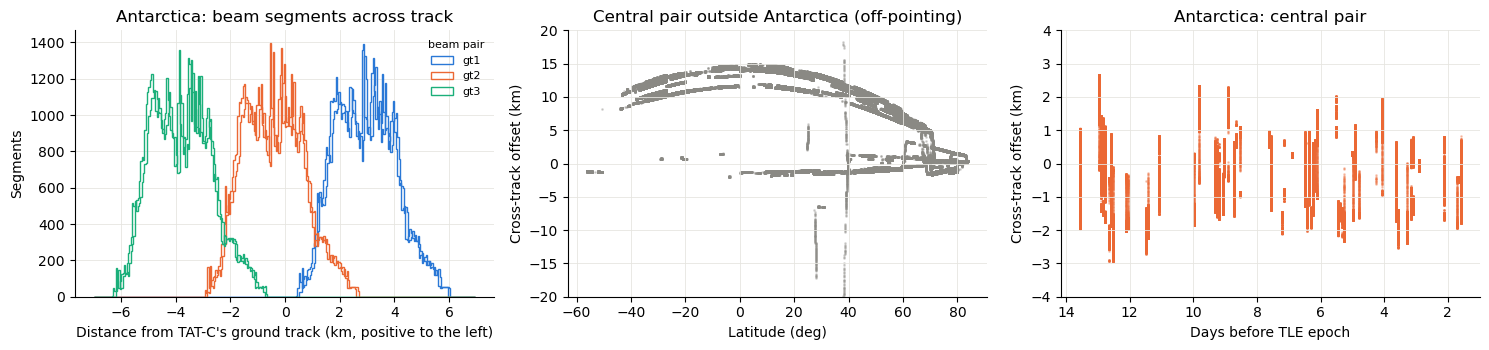

In [5]:
antarctica = segments[segments.region.str.startswith("Antarctica")]
central = antarctica[antarctica.beam.isin(["gt2l", "gt2r"])]
fig, axes = plt.subplots(1, 3, figsize=(15, 3.6))
for beam, color in zip(BEAMS, [BLUE, BLUE, ORANGE, ORANGE, AQUA, AQUA]):
    axes[0].hist(antarctica[antarctica.beam == beam]["cross-track (km)"], bins=np.arange(-7, 7, 0.05), histtype="step", color=color, label=beam[:3] if beam.endswith("l") else None)
axes[0].set(xlabel="Distance from TAT-C's ground track (km, positive to the left)", ylabel="Segments", title="Antarctica: beam segments across track")
axes[0].legend(frameon=False, fontsize=8, title="beam pair", title_fontsize=8)
others = segments[~segments.region.str.startswith("Antarctica") & segments.beam.isin(["gt2l", "gt2r"])]
axes[1].scatter(others.latitude, others["cross-track (km)"], s=1, color=GRAY, alpha=0.3)
axes[1].set(xlabel="Latitude (deg)", ylabel="Cross-track offset (km)", title="Central pair outside Antarctica (off-pointing)", ylim=(-20, 20))
axes[2].scatter(central["days before TLE epoch"], central["cross-track (km)"], s=1, color=ORANGE, alpha=0.3)
axes[2].set(xlabel="Days before TLE epoch", ylabel="Cross-track offset (km)", title="Antarctica: central pair", ylim=(-4, 4))
axes[2].invert_xaxis()
fig.tight_layout()
plt.show()

In Antarctica, where the beams follow the RGTs, the three beam pairs lie 3.4 km apart (medians 3.0, -0.4, and -3.8 km from TAT-C's ground track); within each pair, the weak beam leads the strong beam by 2.5 km along track and lies 90 m to its left. The central pair is within -2.1 to +1.5 km of TAT-C's ground track (5th to 95th percentile), with offsets that vary along each pass: the combined differences between the TLE's orbit, ICESat-2's orbit, and the RGT that ICESat-2's pointing follows. Elsewhere, ICESat-2 points its beams off the RGTs: the central pair lies 8 to 15 km to the left of TAT-C's ground track between 40 deg south and 60 deg north, returning to the RGTs north of about 70 deg north.

## Test 3: Narrow Views

Each beam pair is modeled as a rectangular `PointedInstrument` rolled to the pair's nominal cross-track position (0 and 3.3 km to either side of the ground track) from ICESat-2's 481 km altitude, with a cross-track field of view spanning a ground width from 100 m to 4 km. For a sample of 600 Antarctic segments of each pair (where the beams follow the RGTs), `collect_observations` (within 2 minutes of the segment's time) determines whether TAT-C predicts the observation.

In [6]:
ALTITUDE = 481e3
PAIRS = {"gt1": 3.3e3, "gt2": 0.0, "gt3": -3.3e3}


def angle(distance):
    """Off-nadir angle (deg) of a signed ground distance from nadir, on a spherical Earth."""
    theta = distance / EARTH_MEAN_RADIUS
    return np.degrees(np.arctan2(EARTH_MEAN_RADIUS * np.sin(theta), EARTH_MEAN_RADIUS + ALTITUDE - EARTH_MEAN_RADIUS * np.cos(theta)))


WIDTHS = [100, 250, 500, 1000, 2000, 4000]
sample3 = pd.concat([antarctica[antarctica.beam.str[:3] == pair].sample(600, random_state=1) for pair in PAIRS])


def predicted(row):
    """Whether TAT-C predicts the observation of a segment by its beam pair, for each modeled width."""
    offset = PAIRS[row.beam[:3]]
    point = Point(id=0, latitude=row.latitude, longitude=row.longitude)
    time = row.time.floor("us").to_pydatetime()
    out = {"beam": row.beam}
    for width in WIDTHS:
        view = PointedInstrument(
            name="pair",
            cross_track_field_of_view=angle(offset + width / 2) - angle(offset - width / 2),
            along_track_field_of_view=1,
            roll_angle=(angle(offset + width / 2) + angle(offset - width / 2)) / 2,
            is_rectangular=True,
        )
        obs = collect_observations(point, Satellite(name="ICESat-2", orbit=icesat2, instruments=[view]), time - timedelta(minutes=2), time + timedelta(minutes=2))
        out[width] = not obs.empty
    return out


with concurrent.futures.ThreadPoolExecutor(8) as pool:
    results3 = pd.DataFrame(list(pool.map(predicted, sample3.itertuples())))
table3 = 100 * results3.groupby(results3.beam.str[:3])[WIDTHS].mean()
table3.columns = [f"{w / 1e3:g} km wide (%)" for w in WIDTHS]
table3.loc["all pairs"] = 100 * results3[WIDTHS].mean().to_numpy()
table3.round(1)

,0.1 km wide (%),0.25 km wide (%),0.5 km wide (%),1 km wide (%),2 km wide (%),4 km wide (%)
beam,,,,,,
gt1,3.8,7.5,16.7,29.3,54.5,93.8
gt2,4.0,8.8,16.7,35.2,58.7,93.5
gt3,2.2,9.0,16.5,31.8,59.3,96.3
all pairs,3.3,8.4,16.6,32.1,57.5,94.6


Modeled with their nominal positions, narrow views rarely predict where the beams observe: a 100 m wide view (much wider than the 11 m footprints) predicts 3% of the Antarctic beam segments, a 1 km wide view 32%, and a 2 km wide view 58%. A view about 4 km wide (2 km on either side of the nominal beam position) predicts 95%, matching the spread of cross-track offsets in Test 2.

## Summary

| Test | Result |
| --- | --- |
| 1. Orbit and repeat cycle | ascending nodes within 0.4 s and 2 km over 10 days (3 to 5 s earlier, after an apparent orbit adjustment); 91-day repeat cycle consistent with the TLE's secular rates but not found by `get_repeat_cycle` (drag in SGP4 propagation) |
| 2. Beam tracks | beam pairs 3.4 km apart; central pair within -2.1 to +1.5 km of TAT-C's ground track over Antarctica (RGT pointing), 8 to 15 km off at lower latitudes (off-pointing) |
| 3. Narrow views | a modeled view must be about 4 km wide to predict 95% of the beams' observations (3% for 100 m) |

**Orbit.** A TLE propagated by SGP4 predicts ICESat-2's orbit to within about 2 km and a fraction of a second over the 10 days before its epoch. TAT-C does not identify ICESat-2's 91-day repeat cycle: its search stops at 30 days by default, and even with a longer search, the TLE's drag moves the propagated satellite far from its initial position by the end of the cycle, whereas ICESat-2 is maneuvered to repeat its ground tracks. Confirming long repeat cycles of maintained low orbits would require ignoring drag (for example, from the secular rates alone).

**Narrow instruments.** Where ICESat-2's narrow beams fall is set by its pointing, not by its orbit: the beams follow the RGTs over the ice sheets and are pointed 10 to 15 km off them over land elsewhere. With a TLE, TAT-C locates the RGT-pointed beams to within about 2 km, so a modeled view must be about 4 km wide to capture their observations; predicting individual footprints of such an instrument requires its pointing plan (which a `PointedInstrument`'s roll angle can represent) and a more accurate orbit than a TLE.